,Feature,Importance
4,Torque [Nm],0.182087
3,Rotational speed [rpm],0.169988
8,PWF,0.148105
7,HDF,0.106718
6,TWF,0.092744
9,OSF,0.082951
5,Tool wear [min],0.082581
12,Tool Wear Level,0.054365
11,Temperature Difference,0.043535
1,Air temperature [K],0.018221


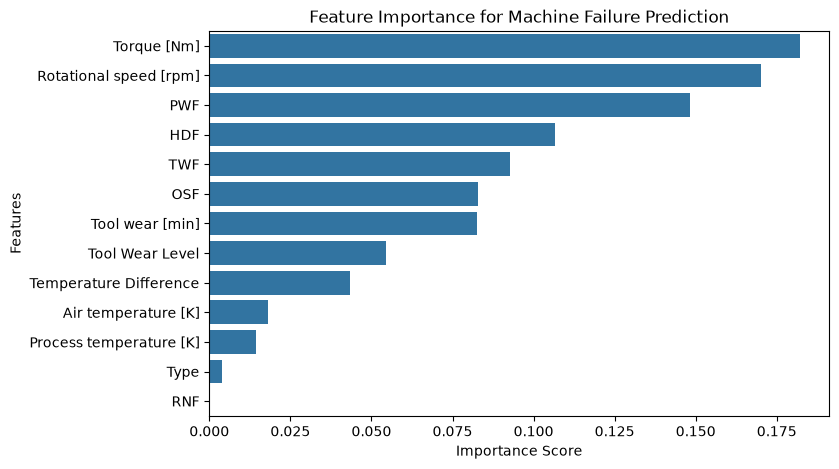

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier


# Load dataset
df = pd.read_csv("../02_Data/Raw/ai4i2020.csv")


# Remove unnecessary columns
df.drop(columns=["UDI", "Product ID"], inplace=True)


# Encode categorical feature
encoder = LabelEncoder()
df["Type"] = encoder.fit_transform(df["Type"])


# Feature Engineering

df["Temperature Difference"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)


df["Tool Wear Level"] = pd.cut(
    df["Tool wear [min]"],
    bins=[0, 100, 200, df["Tool wear [min]"].max()],
    labels=[0, 1, 2],
    include_lowest=True
)

df["Tool Wear Level"] = df["Tool Wear Level"].astype(int)


# Separate features and target

X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]


# Train Random Forest for feature importance

model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

model.fit(X, y)


# Feature importance

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


display(importance)


# Plot feature importance

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Machine Failure Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.savefig(
    "../06_Images/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Industrial Equipment Reliability Intelligence Platform

## Business Insights

This notebook translates machine learning results into practical business insights for predictive maintenance. The objective is to understand how AI-based failure prediction can support maintenance planning and reduce unexpected machine downtime.